In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

/tmp/ipykernel_32870/3884926229.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [24]:
base_dir = '../data/s1/original/'

dfs = []
files = next(os.walk(base_dir))[2]

for file in files:
    dfs.append(pd.read_csv(os.path.join(base_dir, file), encoding='utf-8'))

In [40]:
original_df = pd.concat(dfs, ignore_index=True, sort=False)

In [41]:
original_df = original_df.sort_values(by=['_id'])
original_df.head()

,x,y,cluster,_id
1000,0.683912,0.543504,1,0
1001,0.685701,0.551136,1,1
1002,0.612810,0.570245,1,2
1003,0.635553,0.544047,1,3
1004,0.653693,0.605594,1,4


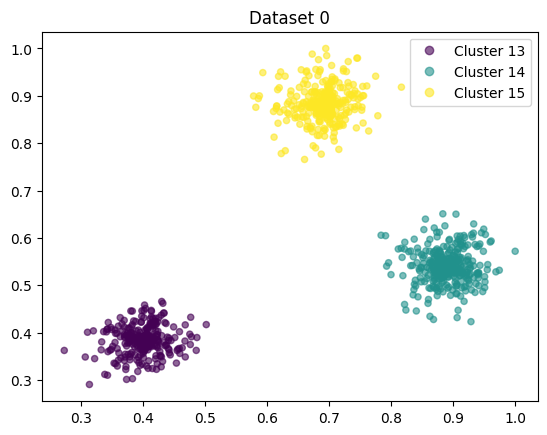

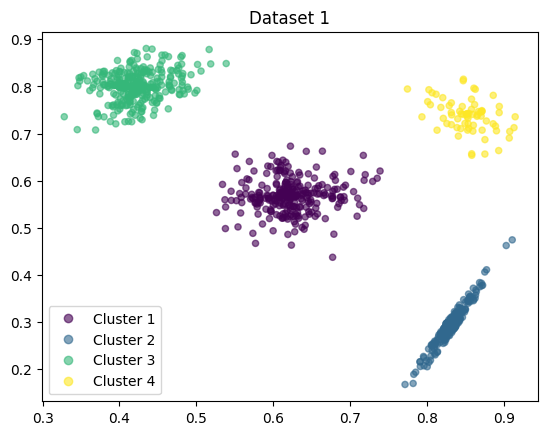

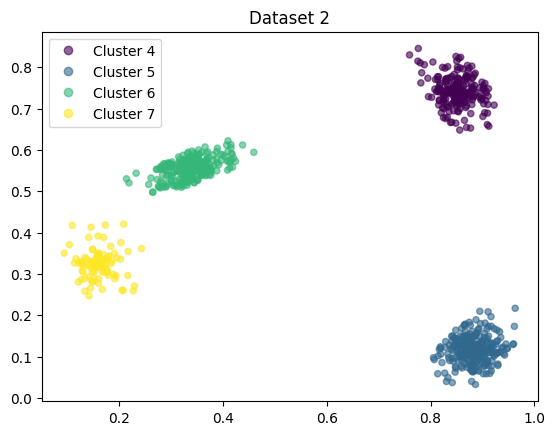

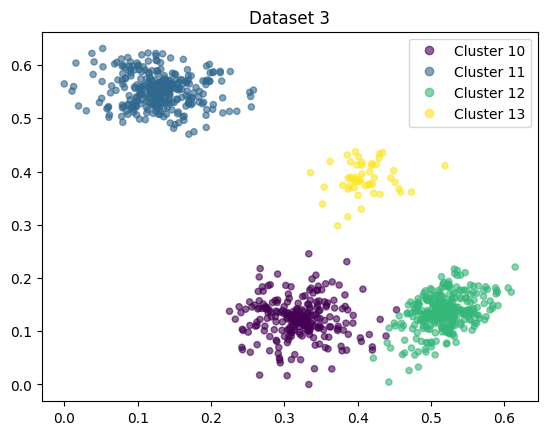

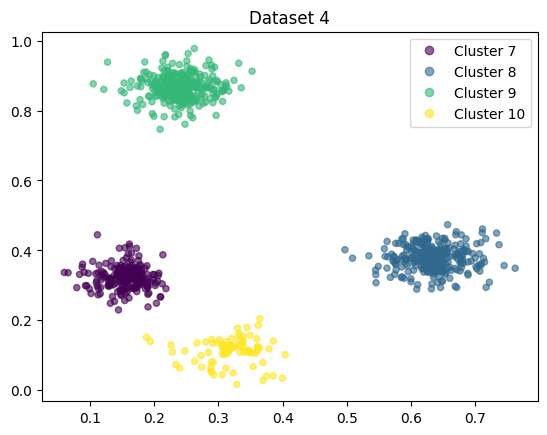

In [36]:
for index, df in enumerate(dfs):
    fig, ax = plt.subplots()
    scatter = plt.scatter(df["x"], df["y"], c=df['cluster'], alpha = 0.6, s=20)
    ax.legend(handles=scatter.legend_elements()[0], labels=map(lambda x: 'Cluster ' + str(x), df['cluster'].unique()))
    ax.set_title(f"Dataset {index}")

In [3]:
def cluster_wise_f_measure(data):
    sum = 0
    unique_clusters_predicted = sorted(data['cluster'].unique())
    for cluster in unique_clusters_predicted:
    	predicted_cluster = data[data['cluster'] == cluster]
    	true_cluster = cluster_with_max_shared(predicted_cluster, data)
    	sum += f_measure(set(predicted_cluster['_id']), set(true_cluster['_id']))
    
    length = len(unique_clusters_predicted)
    return (sum / length)

def f_measure(pred, true):
    value = (2 * len(pred & true)) / (len(true) + len(pred))
    return value


def cluster_with_max_shared(predicted_cluster, data):
	predicted = set(predicted_cluster['_id'])
	true = data['actual_cluster'].unique()
	max_cluster = 0
	max_session = 0

	for label in true:
		cluster = data[data['actual_cluster'] == label]
		same_cluster = len(predicted & set(cluster['_id']))
		if same_cluster > max_cluster:
			max_cluster = same_cluster
			max_session = label
	return data[data['actual_cluster'] == max_session]

def cluster_wise_jaccard(data):
	sum = 0
	unique_clusters_predicted = sorted(data['cluster'].unique())
	for cluster in unique_clusters_predicted:
		predicted_cluster = data[data['cluster'] == cluster]
		true_cluster = cluster_with_max_shared(predicted_cluster, data)
		sum += jaccard_measure(set(predicted_cluster['_id']), set(true_cluster['_id']))

	length = len(unique_clusters_predicted)
	return (sum / length)


def jaccard_measure(y_true, y_pred):
    return (len(y_pred & y_true)) / (len(y_true) + len(y_pred) - len(y_true & y_pred))

In [14]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import numpy as np
import seaborn as sns
from sklearn.metrics import pairwise_distances,silhouette_score

result_metrics = {}

def calculate_distances(data):
    return pairwise_distances(data,data)

def eda_clustering(window=30, data_type='original', is_included=False, num_segments = 4):
    base_dir = f'../results/s1/{data_type}/tabular/{window}/'
    df = pd.read_csv(os.path.join(base_dir, 'final_clustering.csv'), encoding='utf-8')
    df = df[df['segment']<=num_segments]

    if is_included:
        df = df[df['is_included']==True]
    
    df = df.rename(columns={'ids': '_id', 'target': 'actual_cluster'})

    palette = sns.color_palette('hls', n_colors=len(set(df['cluster'])))
    sns.scatterplot(x=df['x'], y=df['y'], hue=df['cluster'], palette=palette).set(title=f"Window {window}")
    plt.show()

    distances = calculate_distances(df[df.columns[:-6]].to_numpy(copy=True))
    if len(df['cluster'].unique()) > 1:
        SI = silhouette_score(distances, df['cluster'])
    else:
        SI = None
    F1 = cluster_wise_f_measure(df)
    JI = cluster_wise_jaccard(df)

    result_metrics[window] = [SI, F1, JI, int(len(df['cluster'].unique()))]


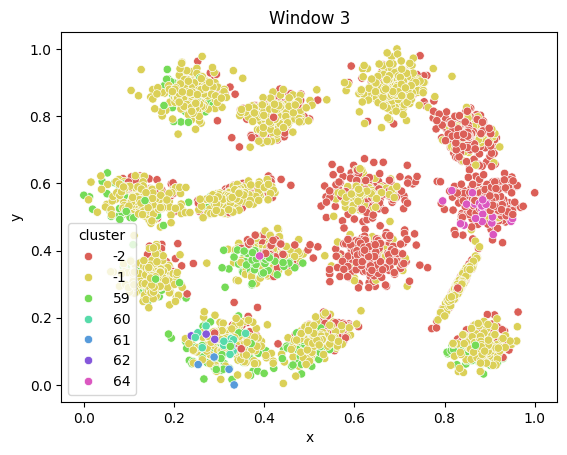

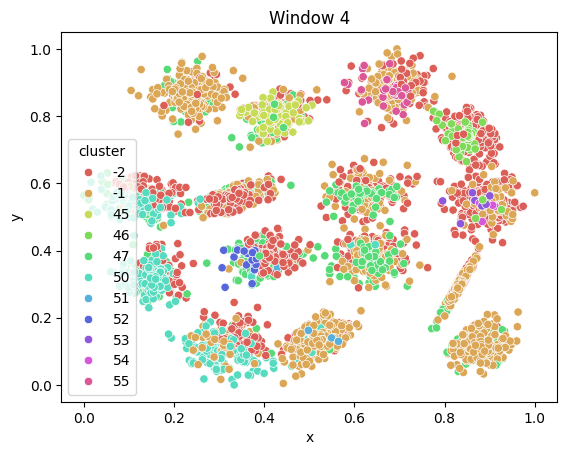

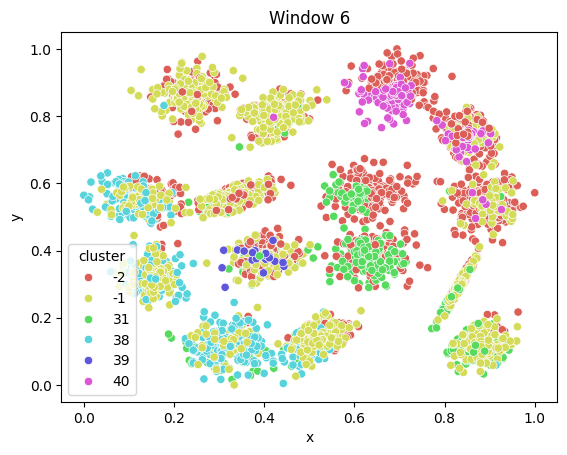

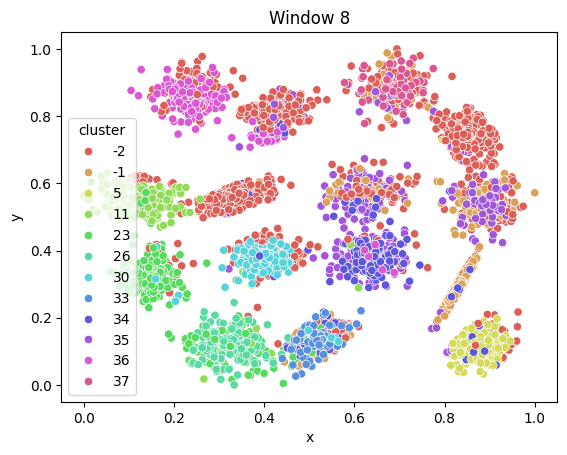

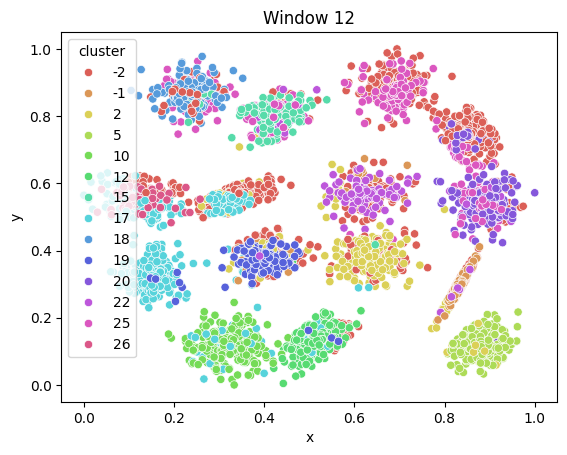

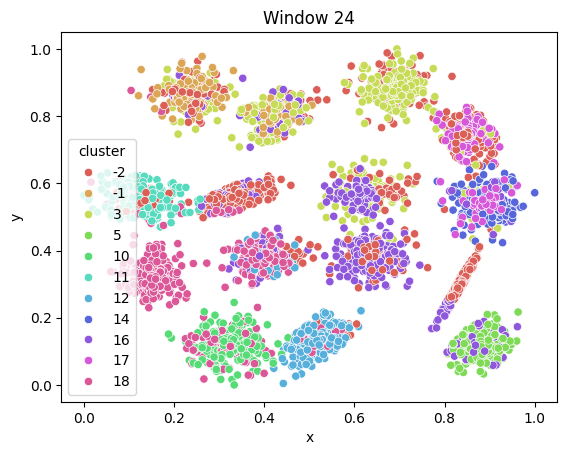

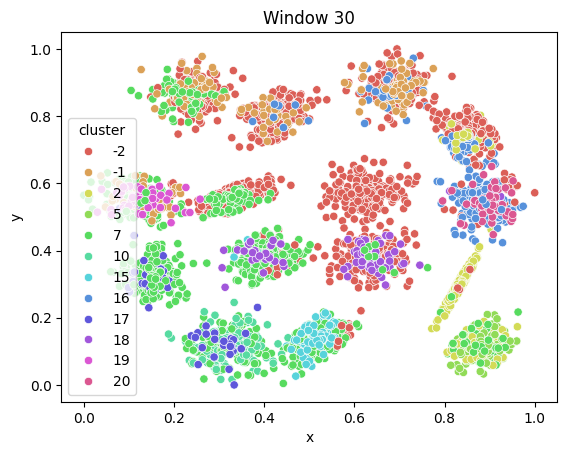

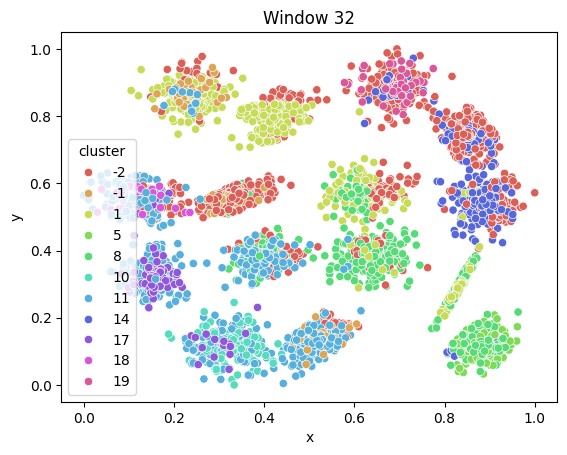

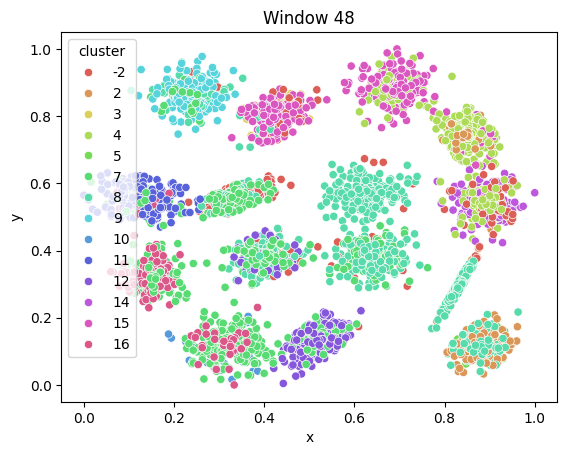

,SI,F1,JI,cluster_count
3,-0.273203,0.144045,0.080450,7.0
4,-0.464849,0.204351,0.120173,11.0
6,-0.204511,0.295697,0.179243,6.0
8,-0.078950,0.579959,0.439240,12.0
12,-0.007113,0.607056,0.475509,14.0
24,0.026546,0.653873,0.523600,11.0
30,-0.208125,0.443211,0.311756,12.0
32,-0.147981,0.434588,0.302672,11.0
48,-0.049273,0.563339,0.419578,14.0


In [48]:
for window in [3,4,6,8,12,24,30,32,48]:
    eda_clustering(window=window, data_type='continuous_previous', is_included=False, num_segments=4)

results_df = pd.DataFrame(result_metrics).T
results_df.columns = ['SI', 'F1', 'JI', 'cluster_count']
results_df

In [42]:
distances = calculate_distances(original_df[original_df.columns[:-2]].to_numpy(copy=True))
if len(original_df['cluster'].unique()) > 1:
    SI = silhouette_score(distances, original_df['cluster'])
else:
    SI = None
# F1 = cluster_wise_f_measure(df)
# JI = cluster_wise_jaccard(df)

SI, int(len(original_df['cluster'].unique()))

(0.6976621415340482, 15)